# Lab Instructions

Create 3 visualizations from a spatial and time-series dataset of your choice.  Describe your dataset including where it came from and the features it contains.  Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import plotly.express as px

trafficDF = pd.read_csv('traffic_accidents.csv')
trafficDF.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


The dataset I chose to use is Traffic Accidents by Oktay Ördekçi (Owner) from Kaggle. This dataset' features are 

crash_date: The date the accident occurred.

traffic_control_device: The type of traffic control device involved (e.g., traffic light, sign).

weather_condition: The weather conditions at the time of the accident.

lighting_condition: The lighting conditions at the time of the accident.

first_crash_type: The initial type of the crash (e.g., head-on, rear-end).

trafficway_type: The type of roadway involved in the accident (e.g., highway, local road).

alignment: The alignment of the road where the accident occurred (e.g., straight, curved).

roadway_surface_cond: The condition of the roadway surface (e.g., dry, wet, icy).

road_defect: Any defects present on the road surface.

crash_type: The overall type of the crash.

intersection_related_i: Whether the accident was related to an intersection.

damage: The extent of the damage caused by the accident.

prim_contributory_cause: The primary cause contributing to the crash.

num_units: The number of vehicles involved in the accident.

most_severe_injury: The most severe injury sustained in the crash.

injuries_total: The total number of injuries reported.

injuries_fatal: The number of fatal injuries resulting from the accident.

injuries_incapacitating: The number of incapacitating injuries.

injuries_non_incapacitating: The number of non-incapacitating injuries.

injuries_reported_not_evident: The number of injuries reported but not visibly evident.

injuries_no_indication: The number of cases with no indication of injury.

crash_hour: The hour the accident occurred.

crash_day_of_week: The day of the week the accident occurred.

crash_month: The month the accident occurred.

In [7]:
trafficDF = pd.read_csv('traffic_accidents.csv')
trafficDF['crash_date'] = pd.to_datetime(trafficDF['crash_date'])
trafficDF['year'] = trafficDF['crash_date'].dt.year
trafficDF['month'] = trafficDF['crash_date'].dt.month
trafficDF['hour'] = trafficDF['crash_date'].dt.hour

trafficDF['year'].value_counts().sort_index()

C:\Users\tmans\AppData\Local\Temp\ipykernel_41772\3162297195.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



year
2013        2
2015     1917
2016     7615
2017    17655
2018    27438
2019    27959
2020    22784
2021    25689
2022    25543
2023    25454
2024    26214
2025     1036
Name: count, dtype: int64

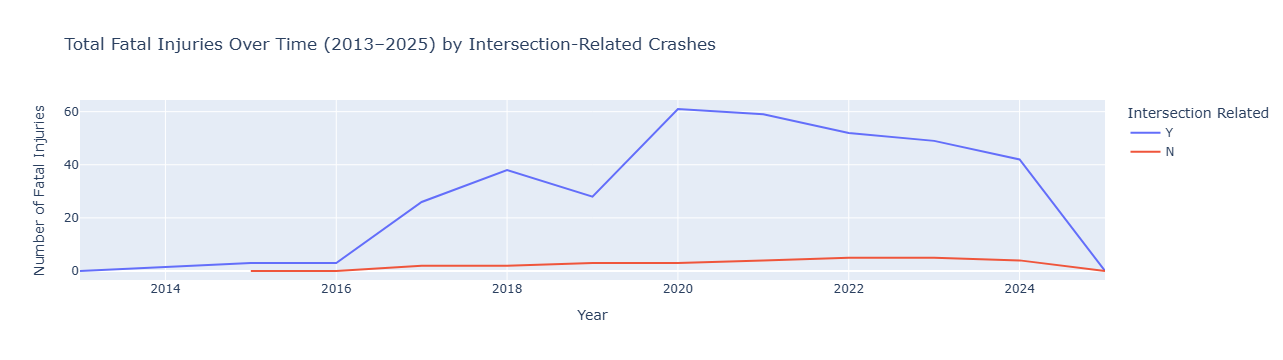

In [5]:
yearly_fatal = trafficDF.groupby(['year', 'intersection_related_i'])['injuries_fatal'].sum().reset_index()

fig1 = px.line(yearly_fatal, x='year', y='injuries_fatal', color='intersection_related_i',
               title='Total Fatal Injuries Over Time (2013–2025) by Intersection-Related Crashes',
               labels={'injuries_fatal': 'Fatal Injuries', 'intersection_related_i': 'Intersection Related'})
fig1.update_layout(xaxis_title='Year', yaxis_title='Number of Fatal Injuries')
fig1.show()

This graph shows that the majority of fatal injuries occor in the same intersections as each other. This could mean that over time these bad intersections just get worse as the population grows.

In [11]:
trafficDF['year'] = trafficDF['crash_date'].dt.year

# Optional: Clean up common 'traffic_control_device' values (Chicago data often has these categories)
# Replace 'NO CONTROLS' or similar with consistent labels if needed
trafficDF['traffic_control_device'] = trafficDF['traffic_control_device'].fillna('UNKNOWN')
# You can add more cleaning if you see messy strings after checking value_counts

# Aggregate: Count of crashes per year per device type
yearly_device = trafficDF.groupby(['year', 'traffic_control_device']).size().reset_index(name='crash_count')

# Optional: Filter to top categories only (to avoid cluttered plots if 20+ unique devices)
top_devices = yearly_device.groupby('traffic_control_device')['crash_count'].sum().nlargest(8).index
yearly_device_top = yearly_device[yearly_device['traffic_control_device'].isin(top_devices)]

yearly_device_top.head()  # Quick peek

,year,traffic_control_device,crash_count
0,2013,NO CONTROLS,1
1,2013,TRAFFIC SIGNAL,1
3,2015,NO CONTROLS,234
4,2015,OTHER,10
5,2015,OTHER REG. SIGN,1


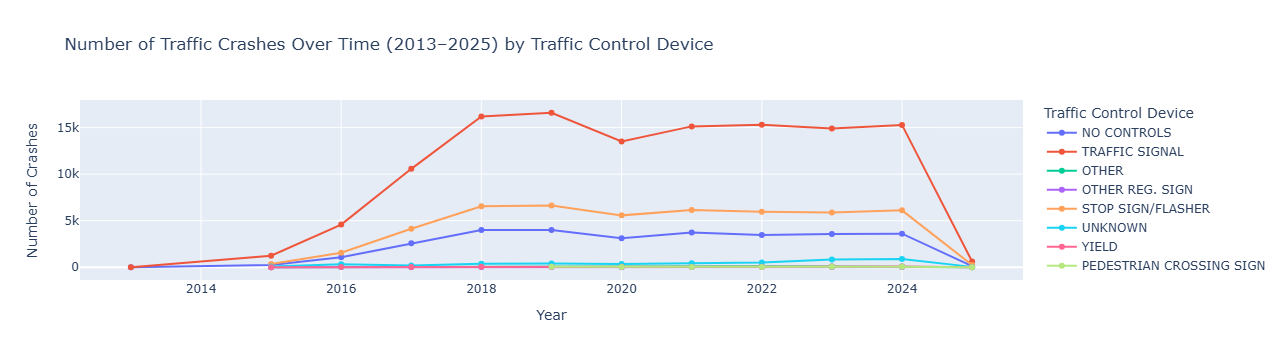

In [12]:
fig = px.line(yearly_device_top,
              x='year',
              y='crash_count',
              color='traffic_control_device',
              markers=True,  # Adds points for each year
              title='Number of Traffic Crashes Over Time (2013–2025) by Traffic Control Device',
              labels={'crash_count': 'Number of Crashes', 'year': 'Year'})

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Number of Crashes',
    legend_title='Traffic Control Device',
    hovermode='x unified'  # Shows all lines' values on hover
)

fig.show()

This chart shows the number of crashes by each control device. It looks crazy that most crashes happen at a traffic signal, but it also makes sense that places with more people would have a traffic lights over time, and with more people comes more crashes. 

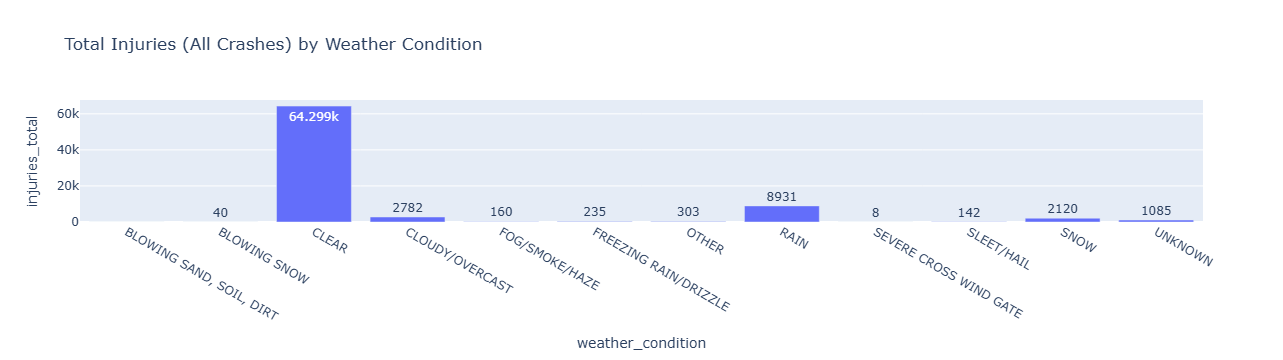

In [16]:
weather_inj_total = trafficDF.groupby('weather_condition')['injuries_total'].sum().reset_index()

fig = px.bar(weather_inj_total, x='weather_condition', y='injuries_total',
             title='Total Injuries (All Crashes) by Weather Condition',
             text_auto=True)

fig.show()

I can safely assume that Weather is not a factor that causes accidents because most occure on a clear day. That said, it might have something to do with more drivers being out when its a nice day rather than when its bad outside.